# Brain-Act Subject-Specific Whole-Brain Simulations (Rates + TVB BOLD)

This notebook runs subject-specific whole-brain AdEx simulations and saves both temporal-average firing rates and TVB Bold monitor outputs. It computes LZc, PCI, and brain-state analyses in both domains across correlated-noise scenarios.

## Mathematical Setup

Correlated noise mixture per node:

$$\eta_i(t)=\sqrt{1-\alpha}\,\xi_i(t)+\sqrt{\alpha}\,\zeta_i(t),\quad 0\le\alpha\le1$$

BOLD sample target condition:

$$T_{sim} \ge T_{transient} + N_{BOLD}\cdot TR$$

We compare complexity and brain states from both domains (rates and BOLD).

In [1]:
from __future__ import annotations

from pathlib import Path
from copy import deepcopy
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from time import perf_counter
import multiprocessing as mp
import itertools
import json
import os
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu, spearmanr

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/matplotlib-cache").resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str(Path("/tmp/xdg-cache").resolve()))
os.environ.setdefault("TVB_USER_HOME", str((PROJECT_ROOT / ".tvb-temp").resolve()))

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tvbtoolkit import WholeBrainConfig, detect_system_specs, list_subjects, run_whole_brain_simulation
from tvbtoolkit.analysis.brain_states import summarize_brain_states
from tvbtoolkit.complexity.measures import lzc_multichannel, pci_casali_like
from tvbtoolkit.datasets.brain_act import load_subject_structural
from tvbtoolkit.workflows.brain_act_dual_domain_parallel import run_dual_domain_job


/var/folders/yy/z6qg2k8n2h3g714cbbr9xp040000gn/T/ipykernel_59341/292242441.py:15: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
WARNING    /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)
 [py.warnings]


2026-04-01 19:24:11,025 - WARNING - py.warnings - /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)



In [2]:
# Runtime configuration
DATASET_ROOT = PROJECT_ROOT / "data" / "doc_patients_new_data" / "converted_structural"

FAST_MODE = False
RUN_ALL_SUBJECTS = True
N_SUBJECTS_PER_COHORT = 3
SEEDS = (0,)

# Run profiles:
# - rates_first: fast first-pass on firing rates only (5000 ms simulation)
# - dual_quick: rates + BOLD with ~30 post-transient BOLD points
# - dual_full: rates + BOLD with ~200 post-transient BOLD points
RUN_PROFILE = "rates_first"  # "rates_first" | "dual_quick" | "dual_full"

# Short/simple output roots per profile
RUN_DIR_MAP = {
    "rates_first": "ba_rates",
    "dual_quick": "ba_dual30",
    "dual_full": "ba_dual200",
}
OUT_ROOT = PROJECT_ROOT / "notebooks" / "outputs" / RUN_DIR_MAP[RUN_PROFILE]
FIG_DIR = OUT_ROOT / "figs"
SIM_DIR = OUT_ROOT / "sims"
METRICS_DIR = OUT_ROOT / "res"
for d in (FIG_DIR, SIM_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Parallelisation controls
USE_PARALLEL = True
PARALLEL_BACKEND = "process"   # "process" (recommended) or "thread"
N_WORKERS = max(1, int(round((os.cpu_count() or 8) * 0.85)))
SHOW_PROGRESS = True
PARALLEL_SCOPE = "subject_condition"  # one simulation per (scenario, cohort, subject)

# Keep BLAS/OpenMP from over-threading inside each process
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

index_path = DATASET_ROOT / "index.json"
if not index_path.exists():
    raise FileNotFoundError(f"Dataset index not found: {index_path}")
DATASET_INDEX = json.loads(index_path.read_text())
PREFERRED_COHORT_ORDER = ("coma", "uws", "mcs", "emcs", "control")
COHORTS = tuple(c for c in PREFERRED_COHORT_ORDER if c in set(DATASET_INDEX.get("cohorts", {}).keys()))

# Wes Anderson-inspired palette (high contrast for MCS/UWS separation)
WES_COHORT_BASE = {
    "control": "#5FA7C6",   # aquatic blue
    "emcs": "#8EA65E",      # moss green
    "mcs": "#E1A84A",       # warm mustard
    "uws": "#C2543D",       # brick red
    "coma": "#6B5876",      # muted violet
}
COHORT_COLORS = {c: WES_COHORT_BASE.get(c, "#6C757D") for c in COHORTS}

COHORT_LABELS = {"coma": "COMA", "uws": "UWS", "mcs": "MCS", "emcs": "EMCS", "control": "CONTROL"}

SED_COLORS = {
    "non_sedated": "#5FA7C6",
    "sedated": "#C2543D",
    "unknown": "#9B9286",
}

COMA_SUBGROUP_COLORS = {
    "coma_non_sedated": "#4F86A8",
    "coma_sedated": "#B14A30",
    "coma_unknown": "#7A7269",
}

if RUN_PROFILE == "rates_first":
    ENABLE_BOLD_ANALYSIS = False
    RATE_MONITOR_HZ = 256.0
    BOLD_TARGET_POINTS = 0
    BOLD_TR_S = 2.4
    TRANSIENT_MS = 2000.0
    simulation_length_ms = 10000.0
elif RUN_PROFILE == "dual_quick":
    ENABLE_BOLD_ANALYSIS = True
    RATE_MONITOR_HZ = 128.0
    BOLD_TARGET_POINTS = 30
    BOLD_TR_S = 2.4
    TRANSIENT_MS = 2000.0
    simulation_length_ms = TRANSIENT_MS + BOLD_TARGET_POINTS * (BOLD_TR_S * 1000.0)
elif RUN_PROFILE == "dual_full":
    ENABLE_BOLD_ANALYSIS = True
    RATE_MONITOR_HZ = 128.0
    BOLD_TARGET_POINTS = 200
    BOLD_TR_S = 2.4
    TRANSIENT_MS = 5000.0
    simulation_length_ms = TRANSIENT_MS + BOLD_TARGET_POINTS * (BOLD_TR_S * 1000.0)
else:
    raise ValueError(f"Unknown RUN_PROFILE={RUN_PROFILE!r}")

RATE_MONITOR_PERIOD_MS = 1000.0 / RATE_MONITOR_HZ
BOLD_PERIOD_MS = BOLD_TR_S * 1000.0
REQUIRED_SIM_MS = TRANSIENT_MS + BOLD_TARGET_POINTS * BOLD_PERIOD_MS

if FAST_MODE:
    simulation_length_ms = min(simulation_length_ms, 120000.0)

PCI_WINDOW_RATE_MS = 300.0
PCI_WINDOW_BOLD_MS = 30000.0
N_STATES = 5

RUN_LOG_PATH = OUT_ROOT / "run_progress.log"
RUN_LOG_PATH.write_text(f"[{datetime.now().isoformat()}] Brain-Act dual-domain run started\n")

print(detect_system_specs())
print({
    "RUN_PROFILE": RUN_PROFILE,
    "ENABLE_BOLD_ANALYSIS": ENABLE_BOLD_ANALYSIS,
    "FAST_MODE": FAST_MODE,
    "RUN_ALL_SUBJECTS": RUN_ALL_SUBJECTS,
    "cohorts": COHORTS,
    "simulation_length_ms": simulation_length_ms,
    "required_for_target_post_transient_bold_points_ms": REQUIRED_SIM_MS,
    "rate_monitor_hz": RATE_MONITOR_HZ,
    "bold_period_ms": BOLD_PERIOD_MS,
    "bold_target_points": BOLD_TARGET_POINTS,
    "seeds": SEEDS,
    "USE_PARALLEL": USE_PARALLEL,
    "PARALLEL_BACKEND": PARALLEL_BACKEND,
    "N_WORKERS": N_WORKERS,
    "out_root": str(OUT_ROOT),
    "run_log": str(RUN_LOG_PATH),
})

if PARALLEL_SCOPE == "subject_condition" and len(SEEDS) != 1:
    raise ValueError("Parallel scope is subject_condition; set SEEDS to a single value (e.g., (0,)).")


SystemSpecs(os_name='Darwin', os_version='Darwin Kernel Version 24.0.0: Tue Sep 24 23:37:36 PDT 2024; root:xnu-11215.1.12~1/RELEASE_ARM64_T6020', machine='arm64', cpu_brand='Apple M2 Max', physical_cores=12, logical_cores=12, memory_gb=64.0, notes='TVB/Brian2 execution path is CPU-based; integrated GPU is not used by default.')
{'RUN_PROFILE': 'rates_first', 'ENABLE_BOLD_ANALYSIS': False, 'FAST_MODE': False, 'RUN_ALL_SUBJECTS': True, 'cohorts': ('coma', 'uws', 'mcs', 'emcs', 'control'), 'simulation_length_ms': 10000.0, 'required_for_target_post_transient_bold_points_ms': 2000.0, 'rate_monitor_hz': 256.0, 'bold_period_ms': 2400.0, 'bold_target_points': 0, 'seeds': (0,), 'USE_PARALLEL': True, 'PARALLEL_BACKEND': 'process', 'N_WORKERS': 10, 'out_root': '/Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_rates', 'run_log': '/Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_rates/run_progress.log'}


In [3]:
SCENARIOS = {
    "private_alpha0": {"label": "Private only (alpha=0.00)", "noise_alpha": 0.00, "shared_noise_mode": "none"},
    "global_alpha_low": {"label": "Global shared, low alpha (0.15)", "noise_alpha": 0.15, "shared_noise_mode": "global"},
    "global_alpha_med": {"label": "Global shared, medium alpha (0.40)", "noise_alpha": 0.40, "shared_noise_mode": "global"},
    "global_alpha_high": {"label": "Global shared, high alpha (0.70)", "noise_alpha": 0.70, "shared_noise_mode": "global"},
    "sc_alpha_med": {"label": "SC-shaped shared, medium alpha (0.40)", "noise_alpha": 0.40, "shared_noise_mode": "connectivity"},
}

BASE_PARAMETER_MODEL = {
    "T": 40.0,
    "P_e": [-0.0498, 0.00506, -0.025, 0.0014, -0.00041, 0.0105, -0.036, 0.0074, 0.0012, -0.0407],
    "P_i": [-0.0514, 0.004, -0.0083, 0.0002, -0.0005, 0.0014, -0.0146, 0.0045, 0.0028, -0.0153],
    "E_L_e": -63.0,
    "E_L_i": -65.0,
    "b_e": 5.0,
    "tau_e_e": 5.0,
    "tau_e_i": 5.0,
    "initial_condition": {
        "E": [0.004, 0.004], "I": [0.010, 0.010],
        "C_ee": [0.0, 0.0], "C_ei": [0.0, 0.0], "C_ii": [0.0, 0.0],
        "W_e": [50.0, 50.0], "W_i": [0.0, 0.0], "noise": [0.0, 0.0],
    },
}

def upper_triangle_vector(x):
    arr = np.asarray(x, dtype=float)
    iu = np.triu_indices_from(arr, k=1)
    return np.asarray(arr[iu], dtype=float)

def safe_pearson(a, b):
    xa = np.asarray(a, dtype=float).reshape(-1)
    xb = np.asarray(b, dtype=float).reshape(-1)
    if xa.size != xb.size or xa.size < 3:
        return float("nan")
    if not np.all(np.isfinite(xa)) or not np.all(np.isfinite(xb)):
        return float("nan")
    if np.std(xa) <= 0.0 or np.std(xb) <= 0.0:
        return float("nan")
    return float(np.corrcoef(xa, xb)[0, 1])

def apply_damage_parity(c, l, cohort):
    c = np.asarray(c, dtype=float).copy()
    l = np.asarray(l, dtype=float).copy()
    np.fill_diagonal(c, 0.0)
    np.fill_diagonal(l, 0.0)
    if cohort.lower() in {"mcs", "uws", "emcs"}:
        mismatch = (c == 0.0) & (l != 0.0)
        if np.any(mismatch):
            l[mismatch] = 0.0
    iu = np.triu_indices_from(c, k=1)
    return c, l, float(np.mean(c[iu] == 0.0))

def extract_rate_and_bold(full_output):
    parsed = []
    for t, d in full_output:
        t = np.asarray(t, dtype=float).reshape(-1)
        d = np.asarray(d)
        if d.ndim == 4:
            x = np.asarray(d[:, 0, :, 0], dtype=float)
        elif d.ndim == 2:
            x = np.asarray(d, dtype=float)
        else:
            x = np.asarray(d).reshape(d.shape[0], -1)
        dt = float(np.median(np.diff(t))) if t.size > 1 else np.inf
        parsed.append((dt, t, x))
    parsed.sort(key=lambda z: z[0])
    if len(parsed) < 2:
        raise ValueError("Expected at least two monitor outputs (rates + BOLD).")
    return parsed[0][1], parsed[0][2], parsed[-1][1], parsed[-1][2]

def compute_pci(x, t_ms, post_window_ms):
    x = np.asarray(x, dtype=float)
    t_ms = np.asarray(t_ms, dtype=float)
    if x.shape[0] < 8:
        return float("nan")
    dt_ms = float(np.median(np.diff(t_ms))) if t_ms.size > 1 else 1.0
    stim_idx = x.shape[0] // 2
    max_half = min(stim_idx, x.shape[0] - stim_idx)
    if max_half < 2:
        return float("nan")
    target_bins = max(2, int(round(post_window_ms / max(dt_ms, 1e-9))))
    window_bins = min(max_half, target_bins)
    return float(pci_casali_like(x, stimulation_index=stim_idx, t_analysis_ms=float(window_bins * dt_ms), dt_ms=dt_ms))

def compute_domain_metrics(x, t_ms, sc, n_states, pci_window_ms):
    lzc = float(lzc_multichannel(x))
    pci = compute_pci(x, t_ms, pci_window_ms)
    bs = summarize_brain_states(np.asarray(x, dtype=float), n_states=n_states, random_seed=0, n_init=10)
    occ = np.asarray(bs.occupancy, dtype=float)
    centers = np.asarray(bs.centers, dtype=float)
    sc_vec = upper_triangle_vector(sc)
    sfc = np.asarray([safe_pearson(row, sc_vec) for row in centers], dtype=float)
    order = np.argsort(np.nan_to_num(sfc, nan=np.inf))
    return {
        "lzc": lzc,
        "pci": pci,
        "occupancy_sfc_sorted": occ[order],
        "sfc_sorted": sfc[order],
    }

def holm_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = pvals.size
    order = np.argsort(pvals)
    out = np.empty(m, dtype=float)
    prev = 0.0
    for rank, idx in enumerate(order):
        adj = (m - rank) * pvals[idx]
        adj = max(adj, prev)
        out[idx] = min(adj, 1.0)
        prev = out[idx]
    return out


In [4]:
cohort_subjects = {}
for cohort in COHORTS:
    subjects = list_subjects(dataset_root=DATASET_ROOT, cohort=cohort)
    sel = subjects if RUN_ALL_SUBJECTS else subjects[:N_SUBJECTS_PER_COHORT]
    cohort_subjects[cohort] = [str(s) for s in sel]

pd.DataFrame([
    {"cohort": c, "n_subjects": len(v), "subjects_preview": ", ".join(v[:6]) + (" ..." if len(v) > 6 else "")}
    for c, v in cohort_subjects.items()
])


,cohort,n_subjects,subjects_preview
0,coma,10,"c0001, c0002, c0003, c0004, c0005, c0006 ..."
1,uws,51,"u0001, u0002, u0003, u0004, u0005, u0006 ..."
2,mcs,75,"m0001, m0002, m0003, m0004, m0005, m0006 ..."
3,emcs,18,"e0001, e0002, e0003, e0004, e0005, e0006 ..."
4,control,35,"c0001, c0002, c0003, c0004, c0005, c0006 ..."


## Cohorts Used in This Analysis

This notebook analyses cohorts in this fixed plotting/statistics order:

**COMA → UWS → MCS → EMCS → CONTROL**

- **COMA** (optional): acute coma subgroup when COMA files are present in the converted dataset.
- **UWS**: *Unresponsive Wakefulness Syndrome*.
- **MCS**: *Minimally Conscious State*.
- **EMCS**: *Emergence from Minimally Conscious State*.
- **CONTROL (CNT)**: healthy/control participants.

If COMA data are present, this notebook also reports COMA subgroup splits by sedation (`coma_non_sedated`, `coma_sedated`).

### Why sedation stratification is included

Sedation status is tracked because sedation can alter large-scale dynamics and therefore affect complexity and state-occupancy results.


## Personalised Whole-Brain Model per Subject

For each subject, we build a **subject-specific whole-brain AdEx mean-field model** (Zerlaut first-order) using that subject's:

- structural connectivity matrix `C` (weights), and
- tract-length matrix `L` (delays via conduction speed).

This means each simulation has personalised long-range coupling topology and delay structure.

For patient cohorts (MCS/UWS), lesion/damage information encoded as zeros in structural matrices is preserved; if a mismatch is found where `C_ij = 0` but `L_ij != 0`, tract length is set to zero for parity and consistency.


## Impulsive Response Definition Used for This Notebook

A separate "impulsivity" scalar is **not** computed here. Instead, for PCI computation we define a perturbation-aligned window by using a midpoint pseudo-stimulation index:

1. Let `stimulation_index = T/2` (midpoint in samples of the analysed signal).
2. Use a symmetric analysis window around this midpoint.
3. Set window length from `post_window_ms` and signal sampling interval `dt_ms`.

This gives a consistent perturbation-style segmentation for resting simulations across all subjects/scenarios.


## PCI Computation (Casali-Style in TVBToolkit)

PCI is computed with `pci_casali_like(...)` for both domains (rates and BOLD):

- Input matrix `X` is channels-by-time (internally normalised if needed).
- Baseline and post-perturbation windows are defined around the midpoint pseudo-stimulation index.
- Signals are binarised relative to baseline significance.
- Spatiotemporal binary patterns are sorted and their 2D Lempel-Ziv complexity is computed.
- Complexity is normalised to produce the PCI value.

This is the Casali-style pipeline (not the deprecated ratio proxy).


## Brain-State Estimation and Occupancy

Brain states are computed separately in each domain using `summarize_brain_states(...)`:

1. Build time-resolved state features from the multiregional signal.
2. Cluster into `N_STATES` using k-means.
3. Compute state occupancy probabilities.
4. Compute state-level SC-FC coupling by correlating each state pattern with the subject's structural connectivity upper triangle.
5. Sort states by SC-FC coupling (low → high) and store occupancy in that ordered basis.

This is done for **rates** and **BOLD**, enabling direct domain comparison.


In [5]:
metric_rows = []
state_rows = []

# Enforce one simulation per (scenario, cohort, subject) job in parallel.
seed0 = int(SEEDS[0])

job_kwargs = [
    {
        "scenario_key": scenario_key,
        "scenario_label": SCENARIOS[scenario_key]["label"],
        "noise_alpha": float(SCENARIOS[scenario_key]["noise_alpha"]),
        "shared_noise_mode": str(SCENARIOS[scenario_key]["shared_noise_mode"]),
        "cohort": cohort,
        "subject_id": subject_id,
        "seed": seed0,
        "dataset_root": str(DATASET_ROOT),
        "sim_dir_root": str(SIM_DIR),
        "simulation_length_ms": float(simulation_length_ms),
        "rate_monitor_period_ms": float(RATE_MONITOR_PERIOD_MS),
        "bold_period_ms": float(BOLD_PERIOD_MS),
        "transient_ms": float(TRANSIENT_MS),
        "n_states": int(N_STATES),
        "pci_window_rate_ms": float(PCI_WINDOW_RATE_MS),
        "pci_window_bold_ms": float(PCI_WINDOW_BOLD_MS),
        "base_parameter_model": deepcopy(BASE_PARAMETER_MODEL),
        "enable_bold": bool(ENABLE_BOLD_ANALYSIS),
    }
    for scenario_key in SCENARIOS.keys()
    for cohort in COHORTS
    for subject_id in cohort_subjects[cohort]
]


def _log_line(msg: str) -> None:
    with RUN_LOG_PATH.open("a") as f:
        f.write(msg + "\n")


_log_line(f"jobs={len(job_kwargs)} backend={PARALLEL_BACKEND} workers={N_WORKERS} scope={PARALLEL_SCOPE}")

if USE_PARALLEL and N_WORKERS > 1:
    if PARALLEL_BACKEND == "process":
        print(f"Dispatching {len(job_kwargs)} jobs on {N_WORKERS} processes")
        executor = ProcessPoolExecutor(max_workers=int(N_WORKERS), mp_context=mp.get_context("spawn"))
    else:
        print(f"Dispatching {len(job_kwargs)} jobs on {N_WORKERS} threads")
        executor = ThreadPoolExecutor(max_workers=int(N_WORKERS))

    with executor as ex:
        submit_ts = {}
        futures = []
        for kw in job_kwargs:
            fut = ex.submit(run_dual_domain_job, **kw)
            submit_ts[fut] = perf_counter()
            futures.append(fut)

        iterator = as_completed(futures)
        if SHOW_PROGRESS and tqdm is not None:
            iterator = tqdm(iterator, total=len(futures), desc="completed jobs")

        n_done = 0
        for fut in iterator:
            n_done += 1
            out = fut.result()
            metric_rows.append(out["metric_row"])
            state_rows.extend(out["state_rows"])

            wall_s = float(perf_counter() - submit_ts[fut])
            runtime_s = float(out.get("runtime_s", float("nan")))
            line = (
                f"[{n_done}/{len(futures)}] scenario={out.get('scenario','')} cohort={out.get('cohort','')} "
                f"subject={out.get('subject_id','')} seed={out.get('seed','')} "
                f"runtime_s={runtime_s:.2f} wall_s={wall_s:.2f}"
            )
            print(line)
            _log_line(line)
else:
    print("Running sequentially")
    iterator = job_kwargs
    if SHOW_PROGRESS and tqdm is not None:
        iterator = tqdm(job_kwargs, desc="scenario/cohort/subject")

    n_done = 0
    for kw in iterator:
        t0 = perf_counter()
        out = run_dual_domain_job(**kw)
        n_done += 1
        metric_rows.append(out["metric_row"])
        state_rows.extend(out["state_rows"])

        wall_s = float(perf_counter() - t0)
        runtime_s = float(out.get("runtime_s", wall_s))
        line = (
            f"[{n_done}/{len(job_kwargs)}] scenario={out.get('scenario','')} cohort={out.get('cohort','')} "
            f"subject={out.get('subject_id','')} seed={out.get('seed','')} "
            f"runtime_s={runtime_s:.2f} wall_s={wall_s:.2f}"
        )
        print(line)
        _log_line(line)

metrics_df = pd.DataFrame(metric_rows)
states_df = pd.DataFrame(state_rows)

# Attach source-file provenance when available (enables COMA subgroup detection).
source_map_path = DATASET_ROOT / "source_subject_map.csv"
if source_map_path.exists():
    src_df = pd.read_csv(source_map_path)
    src_keep = [
        c
        for c in ["subject_id", "source_sc_file", "source_tl_file", "source_subject_index"]
        if c in src_df.columns
    ]
    src_df = src_df[src_keep].drop_duplicates(["subject_id"])
    metrics_df = metrics_df.merge(src_df, on="subject_id", how="left")
    states_df = states_df.merge(src_df, on="subject_id", how="left")
else:
    metrics_df["source_sc_file"] = ""
    states_df["source_sc_file"] = ""


def _derive_coma_subgroup(row: pd.Series) -> str:
    cohort = str(row.get("cohort", "")).strip().lower()
    sed = str(row.get("sedation_group", "")).strip().lower()
    src = str(row.get("source_sc_file", "")).strip().lower()

    has_coma = (cohort == "coma") or ("coma" in src)
    if not has_coma:
        return "non_coma"
    if ("sedated_coma" in src) or (sed == "sedated"):
        return "coma_sedated"
    if ("acute_coma" in src) or (sed == "non_sedated"):
        return "coma_non_sedated"
    return "coma_unknown"


for df in (metrics_df, states_df):
    if not df.empty:
        df["coma_subgroup"] = df.apply(_derive_coma_subgroup, axis=1)

metrics_csv = METRICS_DIR / "dual_domain_metrics.csv"
states_csv = METRICS_DIR / "dual_domain_state_rows.csv"
metrics_df.to_csv(metrics_csv, index=False)
states_df.to_csv(states_csv, index=False)

subject_groups = metrics_df[["cohort", "subject_id", "stage", "sedation_group", "coma_subgroup"]].drop_duplicates(
    ["cohort", "subject_id"]
)
subject_groups_csv = METRICS_DIR / "subject_groups.csv"
subject_groups.to_csv(subject_groups_csv, index=False)

coma_counts = (
    subject_groups[subject_groups["coma_subgroup"].isin(["coma_non_sedated", "coma_sedated", "coma_unknown"])]
    ["coma_subgroup"]
    .value_counts()
    .to_dict()
)
if coma_counts:
    print({"coma_subgroup_subject_counts": coma_counts})

_log_line(f"completed metrics_rows={len(metrics_df)} state_rows={len(states_df)}")
print({
    "metrics_csv": str(metrics_csv),
    "states_csv": str(states_csv),
    "subject_groups_csv": str(subject_groups_csv),
    "run_log": str(RUN_LOG_PATH),
})
print({"metrics_rows": int(metrics_df.shape[0]), "state_rows": int(states_df.shape[0])})
metrics_df.head()


Dispatching 945 jobs on 10 processes


completed jobs:   0%|          | 0/945 [00:00<?, ?it/s]

WARNING    /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)
 [py.warnings]
WARNING    /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)
 [py.warnings]
WARNING    /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)
 [py.warnings]
WARNING    /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)
 [py.warnings]
WARNING    /Users/borjan/miniconda3/lib/python3.

2026-04-01 19:24:12,780 - WARNING - py.warnings - /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)

2026-04-01 19:24:12,804 - WARNING - py.warnings - /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)

2026-04-01 19:24:12,839 - WARNING - py.warnings - /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)

2026-04-01 19:24:12,839 - WARNING - py.warnings - /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for 

,scenario,scenario_label,cohort,stage,sedation,sedation_group,subject_id,seed,sc_zero_fraction_upper,n_rate_samples,n_bold_samples,lzc_rate,pci_rate,lzc_bold,pci_bold,source_sc_file,source_tl_file,source_subject_index,coma_subgroup
0,private_alpha0,Private only (alpha=0.00),coma,acute,non_sedated,sedated,c0002,0,0.122846,2051,0,0.881513,0.515784,NaN,NaN,CNT_send/SC/CNT_SC.mat,CNT_send/SC/CNT_SC_lengths.mat,1,coma_sedated
1,private_alpha0,Private only (alpha=0.00),coma,acute,non_sedated,sedated,c0003,0,0.034707,2051,0,0.875467,0.497641,NaN,NaN,CNT_send/SC/CNT_SC.mat,CNT_send/SC/CNT_SC_lengths.mat,2,coma_sedated
2,private_alpha0,Private only (alpha=0.00),coma,acute,non_sedated,sedated,c0004,0,0.113109,2051,0,0.879608,0.515413,NaN,NaN,CNT_send/SC/CNT_SC.mat,CNT_send/SC/CNT_SC_lengths.mat,3,coma_sedated
3,private_alpha0,Private only (alpha=0.00),coma,acute,sedated,sedated,c0010,0,0.003995,2051,0,0.885696,0.576454,NaN,NaN,CNT_send/SC/CNT_SC.mat,CNT_send/SC/CNT_SC_lengths.mat,9,coma_sedated
4,private_alpha0,Private only (alpha=0.00),coma,acute,non_sedated,sedated,c0005,0,0.072659,2051,0,0.878553,0.417022,NaN,NaN,CNT_send/SC/CNT_SC.mat,CNT_send/SC/CNT_SC_lengths.mat,4,coma_sedated


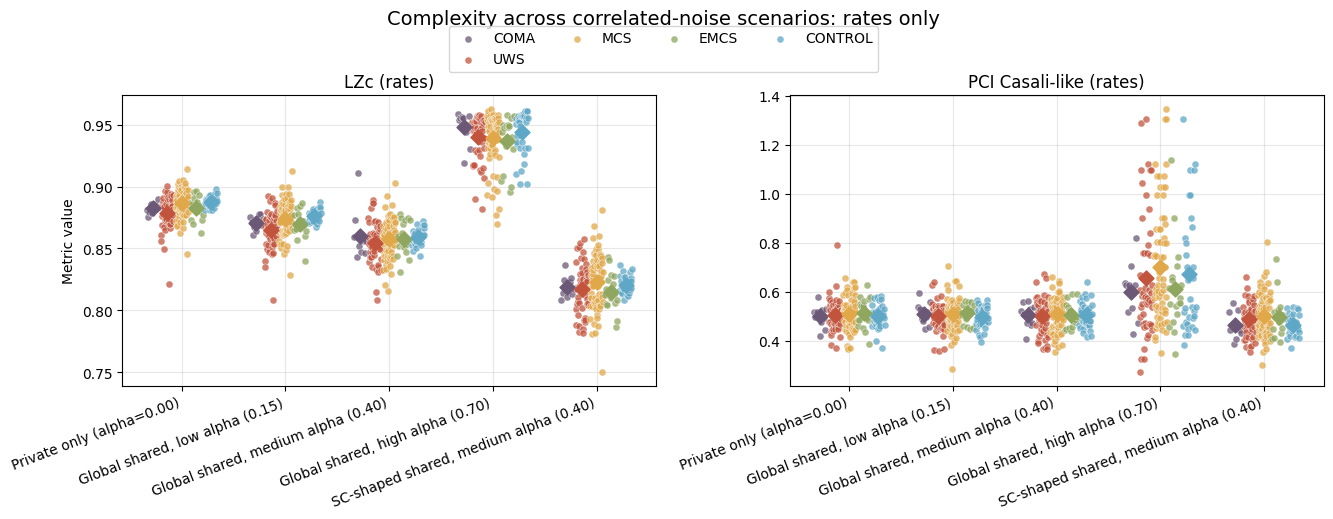

In [6]:
scenario_order = list(SCENARIOS.keys())
cohorts_present = [c for c in COHORTS if c in set(metrics_df["cohort"])]
cohort_offsets = dict(zip(cohorts_present, np.linspace(-0.28, 0.28, max(1, len(cohorts_present)))))

if ENABLE_BOLD_ANALYSIS:
    plots = [
        ("lzc_rate", "LZc (rates)"),
        ("pci_rate", "PCI Casali-like (rates)"),
        ("lzc_bold", "LZc (BOLD)"),
        ("pci_bold", "PCI Casali-like (BOLD)"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.2), sharex=True)
    axs = axes.flat
else:
    plots = [
        ("lzc_rate", "LZc (rates)"),
        ("pci_rate", "PCI Casali-like (rates)"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharex=True)
    axs = axes

for ax, (metric, title) in zip(axs, plots):
    for s_idx, scenario in enumerate(scenario_order):
        sub_s = metrics_df[metrics_df["scenario"] == scenario]
        for cohort in cohorts_present:
            sub = sub_s[sub_s["cohort"] == cohort]
            if sub.empty:
                continue
            y = sub[metric].to_numpy(dtype=float)
            y = y[np.isfinite(y)]
            if y.size == 0:
                continue
            x_center = s_idx + cohort_offsets[cohort]
            x = x_center + np.linspace(-0.06, 0.06, max(1, y.size))[:y.size]
            ax.scatter(x, y, s=26, alpha=0.75, color=COHORT_COLORS[cohort], edgecolor="white", linewidth=0.4,
                       label=COHORT_LABELS.get(cohort, cohort.upper()) if s_idx == 0 else None, zorder=3)
            ax.scatter([x_center], [float(np.mean(y))], marker="D", s=58, color=COHORT_COLORS[cohort], zorder=4)
    ax.set_title(title)
    ax.grid(alpha=0.30)
    ax.set_xticks(np.arange(len(scenario_order)), [SCENARIOS[s]["label"] for s in scenario_order], rotation=21, ha="right")

if ENABLE_BOLD_ANALYSIS:
    axes[0, 0].set_ylabel("Metric value")
    axes[1, 0].set_ylabel("Metric value")
else:
    axes[0].set_ylabel("Metric value")

handles, labels = list(axs)[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.01))
subtitle = "rates vs BOLD" if ENABLE_BOLD_ANALYSIS else "rates only"
fig.suptitle(f"Complexity across correlated-noise scenarios: {subtitle}", y=1.03, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig01_complexity_dual_domain.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig01_complexity_dual_domain.pdf", bbox_inches="tight")
plt.show()


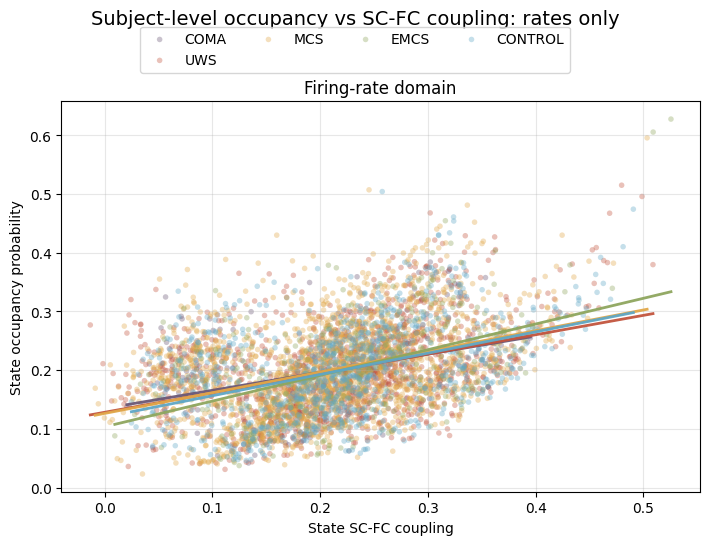

In [7]:
if ENABLE_BOLD_ANALYSIS:
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4), sharey=True)
    configs = [
        (axes[0], "sfc_rate", "occ_rate", "Firing-rate domain"),
        (axes[1], "sfc_bold", "occ_bold", "BOLD domain"),
    ]
else:
    fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.2), sharey=True)
    configs = [(ax, "sfc_rate", "occ_rate", "Firing-rate domain")]

for ax, xcol, ycol, ttl in configs:
    for cohort in cohorts_present:
        sub = states_df[states_df["cohort"] == cohort]
        if sub.empty:
            continue
        x = sub[xcol].to_numpy(dtype=float)
        y = sub[ycol].to_numpy(dtype=float)
        finite = np.isfinite(x) & np.isfinite(y)
        x, y = x[finite], y[finite]
        if x.size == 0:
            continue
        ax.scatter(x, y, s=16, alpha=0.36, color=COHORT_COLORS[cohort], edgecolors="none", label=COHORT_LABELS.get(cohort, cohort.upper()))
        if x.size >= 3 and np.std(x) > 0:
            p = np.polyfit(x, y, deg=1)
            xx = np.linspace(float(np.min(x)), float(np.max(x)), 120)
            yy = p[0] * xx + p[1]
            ax.plot(xx, yy, color=COHORT_COLORS[cohort], lw=2.0, alpha=0.95)
    ax.set_title(ttl)
    ax.set_xlabel("State SC-FC coupling")
    ax.grid(alpha=0.30)

if ENABLE_BOLD_ANALYSIS:
    axes[0].set_ylabel("State occupancy probability")
    handles, labels = axes[1].get_legend_handles_labels()
else:
    ax.set_ylabel("State occupancy probability")
    handles, labels = ax.get_legend_handles_labels()

if handles:
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.02))
subtitle = "rates and BOLD" if ENABLE_BOLD_ANALYSIS else "rates only"
fig.suptitle(f"Subject-level occupancy vs SC-FC coupling: {subtitle}", y=1.04, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_sfc_vs_occupancy_dual_domain.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig02_sfc_vs_occupancy_dual_domain.pdf", bbox_inches="tight")
plt.show()


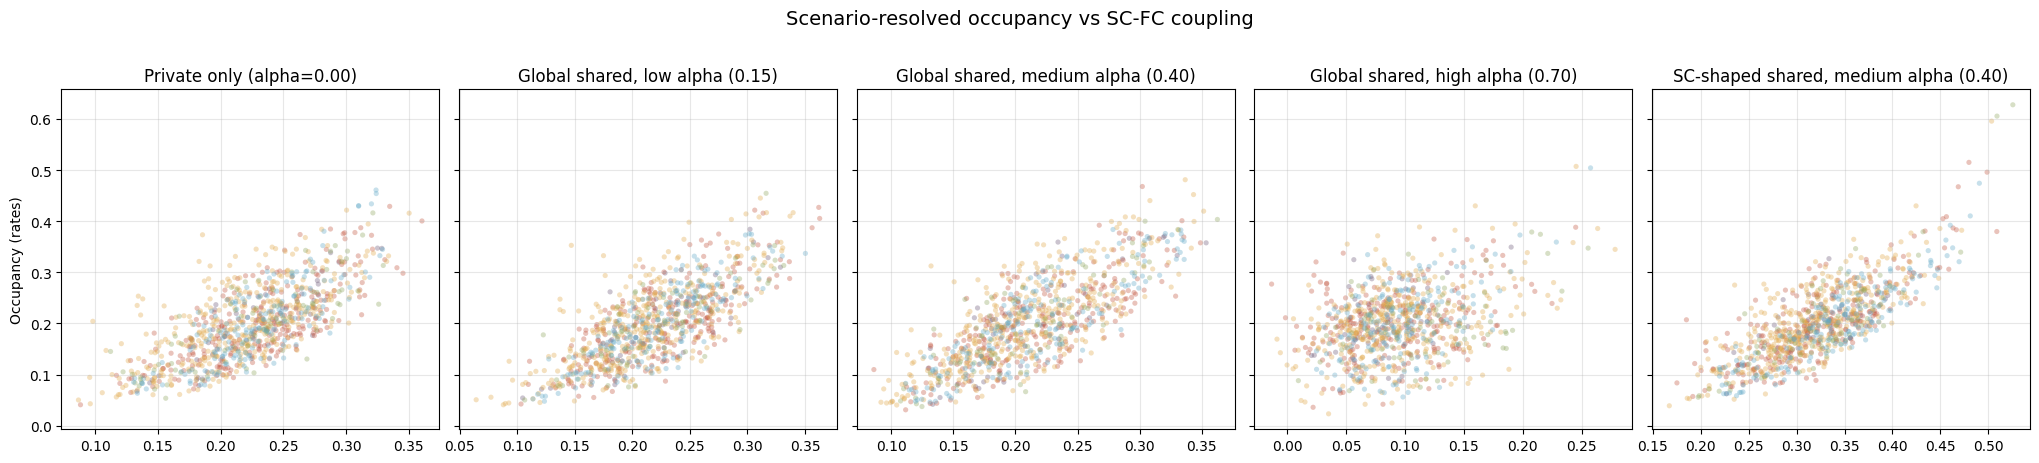

In [8]:
n_s = len(scenario_order)
rows = 2 if ENABLE_BOLD_ANALYSIS else 1
fig, axes = plt.subplots(rows, n_s, figsize=(4.1 * n_s, 4.5 * rows), sharey="row")
if rows == 1:
    axes = np.array([axes])

for col, scenario in enumerate(scenario_order):
    sub_s = states_df[states_df["scenario"] == scenario]

    ax = axes[0, col]
    for cohort in cohorts_present:
        sub = sub_s[sub_s["cohort"] == cohort]
        if sub.empty:
            continue
        x = sub["sfc_rate"].to_numpy(dtype=float)
        y = sub["occ_rate"].to_numpy(dtype=float)
        finite = np.isfinite(x) & np.isfinite(y)
        ax.scatter(x[finite], y[finite], s=14, alpha=0.35, color=COHORT_COLORS[cohort], edgecolors="none")
    ax.set_title(SCENARIOS[scenario]["label"])
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel("Occupancy (rates)")

    if ENABLE_BOLD_ANALYSIS:
        axb = axes[1, col]
        for cohort in cohorts_present:
            sub = sub_s[sub_s["cohort"] == cohort]
            if sub.empty:
                continue
            x = sub["sfc_bold"].to_numpy(dtype=float)
            y = sub["occ_bold"].to_numpy(dtype=float)
            finite = np.isfinite(x) & np.isfinite(y)
            axb.scatter(x[finite], y[finite], s=14, alpha=0.35, color=COHORT_COLORS[cohort], edgecolors="none")
        axb.set_xlabel("State SC-FC coupling")
        axb.grid(alpha=0.3)
        if col == 0:
            axb.set_ylabel("Occupancy (BOLD)")

fig.suptitle("Scenario-resolved occupancy vs SC-FC coupling", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig03_scenario_faceted_sfc_occupancy.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig03_scenario_faceted_sfc_occupancy.pdf", bbox_inches="tight")
plt.show()


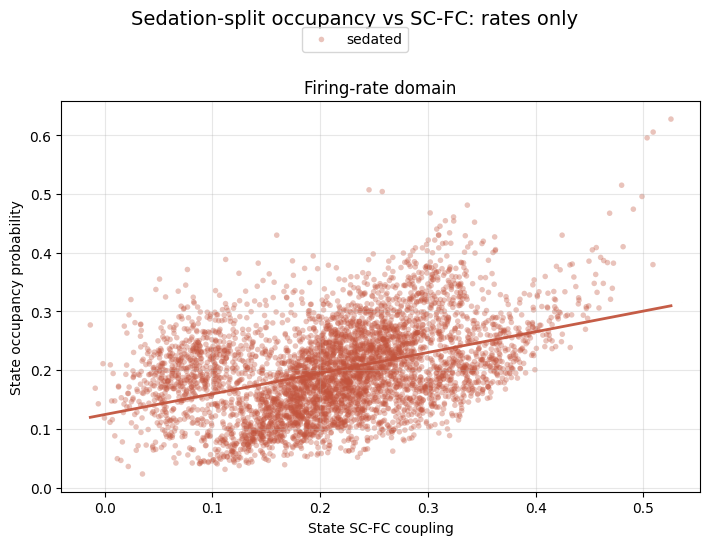

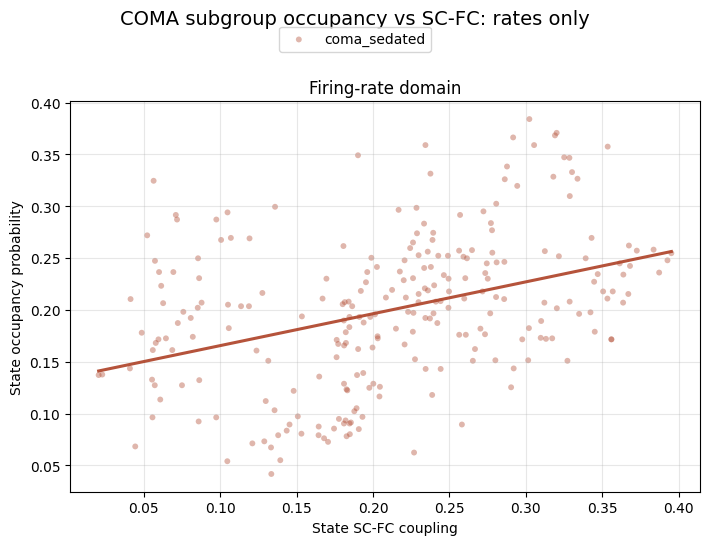

In [9]:
# Sedation-split brain-state view: occupancy vs SFC

sed_groups = [g for g in ["non_sedated", "sedated", "unknown"] if g in set(states_df["sedation_group"])]

if ENABLE_BOLD_ANALYSIS:
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4), sharey=True)
    cfgs = [
        (axes[0], "sfc_rate", "occ_rate", "Firing-rate domain"),
        (axes[1], "sfc_bold", "occ_bold", "BOLD domain"),
    ]
else:
    fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.2), sharey=True)
    cfgs = [(ax, "sfc_rate", "occ_rate", "Firing-rate domain")]

for ax, xcol, ycol, title in cfgs:
    for g in sed_groups:
        sub = states_df[states_df["sedation_group"] == g]
        x = sub[xcol].to_numpy(dtype=float)
        y = sub[ycol].to_numpy(dtype=float)
        fin = np.isfinite(x) & np.isfinite(y)
        x, y = x[fin], y[fin]
        if x.size == 0:
            continue

        ax.scatter(x, y, s=16, alpha=0.35, color=SED_COLORS[g], edgecolors='none', label=g)
        if x.size >= 3 and np.std(x) > 0:
            p = np.polyfit(x, y, deg=1)
            xx = np.linspace(float(np.min(x)), float(np.max(x)), 120)
            yy = p[0] * xx + p[1]
            ax.plot(xx, yy, color=SED_COLORS[g], lw=2.0, alpha=0.95)

    ax.set_title(title)
    ax.set_xlabel("State SC-FC coupling")
    ax.grid(alpha=0.30)

if ENABLE_BOLD_ANALYSIS:
    axes[0].set_ylabel("State occupancy probability")
    handles, labels = axes[1].get_legend_handles_labels()
else:
    ax.set_ylabel("State occupancy probability")
    handles, labels = ax.get_legend_handles_labels()

if handles:
    fig.legend(handles, labels, loc='upper center', ncol=min(3, len(handles)), bbox_to_anchor=(0.5, 1.02))
subtitle = "rates and BOLD" if ENABLE_BOLD_ANALYSIS else "rates only"
fig.suptitle(f"Sedation-split occupancy vs SC-FC: {subtitle}", y=1.04, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig04_sedation_sfc_vs_occupancy.svg", bbox_inches='tight')
fig.savefig(FIG_DIR / "fig04_sedation_sfc_vs_occupancy.pdf", bbox_inches='tight')
plt.show()

# COMA subgroup split (if present in this dataset)
coma_groups = [g for g in ["coma_non_sedated", "coma_sedated", "coma_unknown"] if g in set(states_df["coma_subgroup"])]
if coma_groups:
    if ENABLE_BOLD_ANALYSIS:
        fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4), sharey=True)
        cfgs = [
            (axes[0], "sfc_rate", "occ_rate", "Firing-rate domain"),
            (axes[1], "sfc_bold", "occ_bold", "BOLD domain"),
        ]
    else:
        fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.2), sharey=True)
        cfgs = [(ax, "sfc_rate", "occ_rate", "Firing-rate domain")]

    for ax, xcol, ycol, title in cfgs:
        for g in coma_groups:
            sub = states_df[states_df["coma_subgroup"] == g]
            x = sub[xcol].to_numpy(dtype=float)
            y = sub[ycol].to_numpy(dtype=float)
            fin = np.isfinite(x) & np.isfinite(y)
            x, y = x[fin], y[fin]
            if x.size == 0:
                continue
            clr = COMA_SUBGROUP_COLORS.get(g, "#666666")
            ax.scatter(x, y, s=18, alpha=0.40, color=clr, edgecolors='none', label=g)
            if x.size >= 3 and np.std(x) > 0:
                p = np.polyfit(x, y, deg=1)
                xx = np.linspace(float(np.min(x)), float(np.max(x)), 120)
                yy = p[0] * xx + p[1]
                ax.plot(xx, yy, color=clr, lw=2.2, alpha=0.95)

        ax.set_title(title)
        ax.set_xlabel("State SC-FC coupling")
        ax.grid(alpha=0.30)

    if ENABLE_BOLD_ANALYSIS:
        axes[0].set_ylabel("State occupancy probability")
        handles, labels = axes[1].get_legend_handles_labels()
    else:
        ax.set_ylabel("State occupancy probability")
        handles, labels = ax.get_legend_handles_labels()

    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=min(3, len(handles)), bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"COMA subgroup occupancy vs SC-FC: {subtitle}", y=1.04, fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig04b_coma_subgroups_sfc_vs_occupancy.svg", bbox_inches='tight')
    fig.savefig(FIG_DIR / "fig04b_coma_subgroups_sfc_vs_occupancy.pdf", bbox_inches='tight')
    plt.show()


In [10]:
pairwise = list(itertools.combinations(cohorts_present, 2))

def run_unpaired_stats(df, metric_col):
    omni_rows, pair_rows = [], []
    for scenario in scenario_order:
        sub_s = df[df["scenario"] == scenario]
        vals = [sub_s[sub_s["cohort"] == c][metric_col].to_numpy(dtype=float) for c in cohorts_present]
        vals = [v[np.isfinite(v)] for v in vals]
        if any(v.size == 0 for v in vals):
            continue
        H, p_kw = kruskal(*vals)
        omni_rows.append({"scenario": scenario, "metric": metric_col, "H": float(H), "p_kw": float(p_kw)})

        p_raw, tmp = [], []
        for a, b in pairwise:
            xa = sub_s[sub_s["cohort"] == a][metric_col].to_numpy(dtype=float)
            xa = xa[np.isfinite(xa)]
            xb = sub_s[sub_s["cohort"] == b][metric_col].to_numpy(dtype=float)
            xb = xb[np.isfinite(xb)]
            U, p = mannwhitneyu(xa, xb, alternative="two-sided")
            p_raw.append(p)
            tmp.append({"scenario": scenario, "metric": metric_col, "contrast": f"{a} vs {b}", "U": float(U), "p_raw": float(p),
                        "median_a": float(np.median(xa)), "median_b": float(np.median(xb)), "n_a": int(xa.size), "n_b": int(xb.size)})

        p_adj = holm_correct(np.asarray(p_raw, dtype=float))
        for row, pa in zip(tmp, p_adj):
            row["p_holm"] = float(pa)
            pair_rows.append(row)
    return pd.DataFrame(omni_rows), pd.DataFrame(pair_rows)

metrics_to_test = ["lzc_rate", "pci_rate"] if not ENABLE_BOLD_ANALYSIS else ["lzc_rate", "pci_rate", "lzc_bold", "pci_bold"]
omni_all, pair_all = [], []
for m in metrics_to_test:
    o, p = run_unpaired_stats(metrics_df, m)
    omni_all.append(o)
    pair_all.append(p)

omni_df = pd.concat(omni_all, ignore_index=True) if omni_all else pd.DataFrame()
pair_df = pd.concat(pair_all, ignore_index=True) if pair_all else pd.DataFrame()

omni_csv = METRICS_DIR / "stats_kruskal_by_scenario.csv"
pair_csv = METRICS_DIR / "stats_pairwise_mannwhitney_holm.csv"
omni_df.to_csv(omni_csv, index=False)
pair_df.to_csv(pair_csv, index=False)

print({"omnibus_stats_csv": str(omni_csv), "pairwise_stats_csv": str(pair_csv)})
display(omni_df)
display(pair_df.head(60))


{'omnibus_stats_csv': '/Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_rates/res/stats_kruskal_by_scenario.csv', 'pairwise_stats_csv': '/Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_rates/res/stats_pairwise_mannwhitney_holm.csv'}


,scenario,metric,H,p_kw
0,private_alpha0,lzc_rate,18.100592,0.001179
1,global_alpha_low,lzc_rate,21.042365,0.000311
2,global_alpha_med,lzc_rate,4.096147,0.393150
3,global_alpha_high,lzc_rate,7.785597,0.099755
4,sc_alpha_med,lzc_rate,5.312682,0.256692
5,private_alpha0,pci_rate,1.107641,0.893058
6,global_alpha_low,pci_rate,1.539678,0.819591
7,global_alpha_med,pci_rate,0.971577,0.914075
8,global_alpha_high,pci_rate,2.849684,0.583287
9,sc_alpha_med,pci_rate,6.556018,0.161295


,scenario,metric,contrast,U,p_raw,median_a,median_b,n_a,n_b,p_holm
0,private_alpha0,lzc_rate,coma vs uws,282.0,0.605684,0.882791,0.881778,10,51,1.000000
1,private_alpha0,lzc_rate,coma vs mcs,256.0,0.106024,0.882791,0.888526,10,75,0.636142
2,private_alpha0,lzc_rate,coma vs emcs,76.0,0.517454,0.882791,0.884332,10,18,1.000000
3,private_alpha0,lzc_rate,coma vs control,69.0,0.003974,0.882791,0.887425,10,35,0.031789
4,private_alpha0,lzc_rate,uws vs mcs,1254.0,0.001074,0.881778,0.888526,51,75,0.009666
5,private_alpha0,lzc_rate,uws vs emcs,384.5,0.311900,0.881778,0.884332,51,18,1.000000
6,private_alpha0,lzc_rate,uws vs control,501.0,0.000588,0.881778,0.887425,51,35,0.005880
7,private_alpha0,lzc_rate,mcs vs emcs,823.0,0.151476,0.888526,0.884332,75,18,0.757378
8,private_alpha0,lzc_rate,mcs vs control,1297.0,0.923312,0.888526,0.887425,75,35,1.000000
9,private_alpha0,lzc_rate,emcs vs control,206.0,0.041574,0.884332,0.887425,18,35,0.291017


In [11]:
# Sedation-stratified differences (sedated vs non_sedated) per scenario
sed_stats_rows = []
for scenario in scenario_order:
    sub_s = metrics_df[metrics_df["scenario"] == scenario]
    sub_s = sub_s[sub_s["sedation_group"].isin(["sedated", "non_sedated"])]
    for metric in (["lzc_rate", "pci_rate"] if not ENABLE_BOLD_ANALYSIS else ["lzc_rate", "pci_rate", "lzc_bold", "pci_bold"]):
        xa = sub_s[sub_s["sedation_group"] == "sedated"][metric].to_numpy(dtype=float)
        xa = xa[np.isfinite(xa)]
        xb = sub_s[sub_s["sedation_group"] == "non_sedated"][metric].to_numpy(dtype=float)
        xb = xb[np.isfinite(xb)]
        if xa.size == 0 or xb.size == 0:
            continue
        U, p = mannwhitneyu(xa, xb, alternative="two-sided")
        sed_stats_rows.append({
            "scenario": scenario,
            "metric": metric,
            "U": float(U),
            "p_raw": float(p),
            "median_sedated": float(np.median(xa)),
            "median_non_sedated": float(np.median(xb)),
            "n_sedated": int(xa.size),
            "n_non_sedated": int(xb.size),
        })

sed_stats_df = pd.DataFrame(sed_stats_rows)
if not sed_stats_df.empty:
    p_adj = holm_correct(sed_stats_df["p_raw"].to_numpy(dtype=float))
    sed_stats_df["p_holm"] = p_adj

sed_stats_csv = METRICS_DIR / "stats_sedated_vs_non_sedated.csv"
sed_stats_df.to_csv(sed_stats_csv, index=False)
print({"sedation_stats_csv": str(sed_stats_csv)})
display(sed_stats_df)


{'sedation_stats_csv': '/Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_rates/res/stats_sedated_vs_non_sedated.csv'}


""


In [12]:
# Association summaries for non-split (cohort) and split (sedation-group) alternatives

# 1) Non-split: cohort-level associations
assoc_rows = []
for scenario in scenario_order:
    sub_s = states_df[states_df["scenario"] == scenario]
    for cohort in ["all", *cohorts_present]:
        sub = sub_s if cohort == "all" else sub_s[sub_s["cohort"] == cohort]
        if sub.empty:
            continue

        xr = sub["sfc_rate"].to_numpy(dtype=float)
        yr = sub["occ_rate"].to_numpy(dtype=float)
        fr = np.isfinite(xr) & np.isfinite(yr)
        rr, pr = spearmanr(xr[fr], yr[fr]) if np.sum(fr) >= 3 else (float("nan"), float("nan"))

        row = {
            "scenario": scenario,
            "group_type": "cohort",
            "group": cohort,
            "rho_rate": float(rr),
            "p_rate": float(pr),
            "n_points": int(sub.shape[0]),
        }

        if ENABLE_BOLD_ANALYSIS:
            xb = sub["sfc_bold"].to_numpy(dtype=float)
            yb = sub["occ_bold"].to_numpy(dtype=float)
            fb = np.isfinite(xb) & np.isfinite(yb)
            rb, pb = spearmanr(xb[fb], yb[fb]) if np.sum(fb) >= 3 else (float("nan"), float("nan"))
            row["rho_bold"] = float(rb)
            row["p_bold"] = float(pb)

        assoc_rows.append(row)

assoc_df = pd.DataFrame(assoc_rows)
assoc_csv = METRICS_DIR / "assoc_spearman_sfc_occupancy_by_cohort.csv"
assoc_df.to_csv(assoc_csv, index=False)
print({"assoc_by_cohort_csv": str(assoc_csv)})
display(assoc_df)

# 2) Split alternative: sedation-group associations
sed_assoc_rows = []
sed_groups = [g for g in ["non_sedated", "sedated", "unknown"] if g in set(states_df["sedation_group"])]
for scenario in scenario_order:
    sub_s = states_df[states_df["scenario"] == scenario]
    for g in ["all", *sed_groups]:
        sub = sub_s if g == "all" else sub_s[sub_s["sedation_group"] == g]
        if sub.empty:
            continue

        xr = sub["sfc_rate"].to_numpy(dtype=float)
        yr = sub["occ_rate"].to_numpy(dtype=float)
        fr = np.isfinite(xr) & np.isfinite(yr)
        rr, pr = spearmanr(xr[fr], yr[fr]) if np.sum(fr) >= 3 else (float("nan"), float("nan"))

        row = {
            "scenario": scenario,
            "group_type": "sedation_group",
            "group": g,
            "rho_rate": float(rr),
            "p_rate": float(pr),
            "n_points": int(sub.shape[0]),
        }

        if ENABLE_BOLD_ANALYSIS:
            xb = sub["sfc_bold"].to_numpy(dtype=float)
            yb = sub["occ_bold"].to_numpy(dtype=float)
            fb = np.isfinite(xb) & np.isfinite(yb)
            rb, pb = spearmanr(xb[fb], yb[fb]) if np.sum(fb) >= 3 else (float("nan"), float("nan"))
            row["rho_bold"] = float(rb)
            row["p_bold"] = float(pb)

        sed_assoc_rows.append(row)

sed_assoc_df = pd.DataFrame(sed_assoc_rows)
sed_assoc_csv = METRICS_DIR / "assoc_spearman_sfc_occupancy_by_sedation.csv"
sed_assoc_df.to_csv(sed_assoc_csv, index=False)
print({"assoc_by_sedation_csv": str(sed_assoc_csv)})
display(sed_assoc_df)

# 3) COMA subgroup associations (only when coma subgroup rows exist)
coma_assoc_rows = []
coma_groups = [g for g in ["coma_non_sedated", "coma_sedated", "coma_unknown"] if g in set(states_df["coma_subgroup"])]
for scenario in scenario_order:
    sub_s = states_df[states_df["scenario"] == scenario]
    for g in ["all", *coma_groups]:
        sub = sub_s[sub_s["coma_subgroup"].isin(coma_groups)] if g == "all" else sub_s[sub_s["coma_subgroup"] == g]
        if sub.empty:
            continue

        xr = sub["sfc_rate"].to_numpy(dtype=float)
        yr = sub["occ_rate"].to_numpy(dtype=float)
        fr = np.isfinite(xr) & np.isfinite(yr)
        rr, pr = spearmanr(xr[fr], yr[fr]) if np.sum(fr) >= 3 else (float("nan"), float("nan"))

        row = {
            "scenario": scenario,
            "group_type": "coma_subgroup",
            "group": g,
            "rho_rate": float(rr),
            "p_rate": float(pr),
            "n_points": int(sub.shape[0]),
        }

        if ENABLE_BOLD_ANALYSIS:
            xb = sub["sfc_bold"].to_numpy(dtype=float)
            yb = sub["occ_bold"].to_numpy(dtype=float)
            fb = np.isfinite(xb) & np.isfinite(yb)
            rb, pb = spearmanr(xb[fb], yb[fb]) if np.sum(fb) >= 3 else (float("nan"), float("nan"))
            row["rho_bold"] = float(rb)
            row["p_bold"] = float(pb)

        coma_assoc_rows.append(row)

coma_assoc_df = pd.DataFrame(coma_assoc_rows)
coma_assoc_csv = METRICS_DIR / "assoc_spearman_sfc_occupancy_by_coma_subgroup.csv"
coma_assoc_df.to_csv(coma_assoc_csv, index=False)
print({"assoc_by_coma_subgroup_csv": str(coma_assoc_csv)})
display(coma_assoc_df)


{'assoc_by_cohort_csv': '/Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_rates/res/assoc_spearman_sfc_occupancy_by_cohort.csv'}


,scenario,group_type,group,rho_rate,p_rate,n_points
0,private_alpha0,cohort,all,0.711341,1.418529e-146,945
1,private_alpha0,cohort,coma,0.856580,2.142550e-15,50
2,private_alpha0,cohort,uws,0.724409,9.268568e-43,255
3,private_alpha0,cohort,mcs,0.657641,8.168794e-48,375
4,private_alpha0,cohort,emcs,0.793854,1.038140e-20,90
5,private_alpha0,cohort,control,0.756959,8.601032e-34,175
6,global_alpha_low,cohort,all,0.732718,8.425532e-160,945
7,global_alpha_low,cohort,coma,0.731128,1.647412e-09,50
8,global_alpha_low,cohort,uws,0.731999,4.672015e-44,255
9,global_alpha_low,cohort,mcs,0.686647,1.343362e-53,375


{'assoc_by_sedation_csv': '/Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_rates/res/assoc_spearman_sfc_occupancy_by_sedation.csv'}


,scenario,group_type,group,rho_rate,p_rate,n_points
0,private_alpha0,sedation_group,all,0.711341,1.418529e-146,945
1,private_alpha0,sedation_group,sedated,0.711341,1.418529e-146,945
2,global_alpha_low,sedation_group,all,0.732718,8.425532e-160,945
3,global_alpha_low,sedation_group,sedated,0.732718,8.425532e-160,945
4,global_alpha_med,sedation_group,all,0.767714,1.836002e-184,945
5,global_alpha_med,sedation_group,sedated,0.767714,1.836002e-184,945
6,global_alpha_high,sedation_group,all,0.300236,3.878592e-21,945
7,global_alpha_high,sedation_group,sedated,0.300236,3.878592e-21,945
8,sc_alpha_med,sedation_group,all,0.770187,2.273430e-186,945
9,sc_alpha_med,sedation_group,sedated,0.770187,2.273430e-186,945


{'assoc_by_coma_subgroup_csv': '/Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/ba_rates/res/assoc_spearman_sfc_occupancy_by_coma_subgroup.csv'}


,scenario,group_type,group,rho_rate,p_rate,n_points
0,private_alpha0,coma_subgroup,all,0.856580,2.142550e-15,50
1,private_alpha0,coma_subgroup,coma_sedated,0.856580,2.142550e-15,50
2,global_alpha_low,coma_subgroup,all,0.731128,1.647412e-09,50
3,global_alpha_low,coma_subgroup,coma_sedated,0.731128,1.647412e-09,50
4,global_alpha_med,coma_subgroup,all,0.819151,3.580702e-13,50
5,global_alpha_med,coma_subgroup,coma_sedated,0.819151,3.580702e-13,50
6,global_alpha_high,coma_subgroup,all,0.367256,8.700889e-03,50
7,global_alpha_high,coma_subgroup,coma_sedated,0.367256,8.700889e-03,50
8,sc_alpha_med,coma_subgroup,all,0.685366,3.997736e-08,50
9,sc_alpha_med,coma_subgroup,coma_sedated,0.685366,3.997736e-08,50


## Saved Outputs

- Per-seed arrays: `notebooks/outputs/<run_dir>/sims/.../seed_XXX.npz`
- Metrics tables: `notebooks/outputs/<run_dir>/res/`
- Figures: `notebooks/outputs/<run_dir>/figs/`
- Runtime log: `notebooks/outputs/<run_dir>/run_progress.log`

Key CSV files:
- `dual_domain_metrics.csv`
- `dual_domain_state_rows.csv`
- `subject_groups.csv`
- `stats_kruskal_by_scenario.csv`
- `stats_pairwise_mannwhitney_holm.csv`
- `stats_sedated_vs_non_sedated.csv`
- `assoc_spearman_sfc_occupancy_by_cohort.csv`
- `assoc_spearman_sfc_occupancy_by_sedation.csv`
- `assoc_spearman_sfc_occupancy_by_coma_subgroup.csv`

Additional COMA split figure (if COMA subgroup is present):
- `fig04b_coma_subgroups_sfc_vs_occupancy.svg` / `.pdf`
